Always Accept Total Reward: -5500
Priority + ICU Total Reward: -393
Conservative + ICU Total Reward: -235
Random Total Reward: -1388


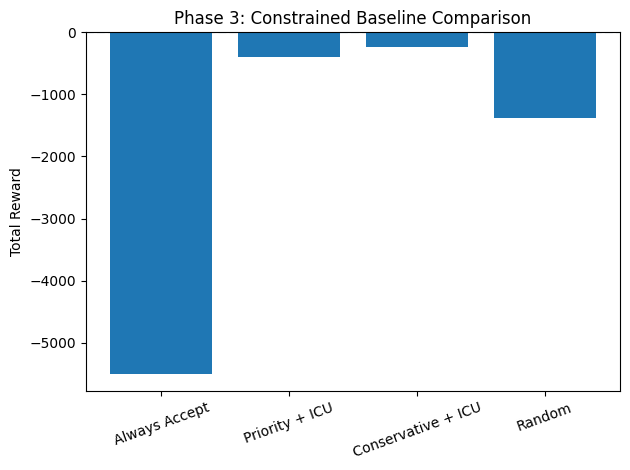

In [1]:
import sys
import os
import random
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils.hospital_env import HospitalEnv


random.seed(42)


data = pd.read_csv("../data/synthetic_hospital_data.csv")


def safe_step(env, action):
    result = env.step(action)

    if len(result) == 3:
        next_state, reward, done = result
    elif len(result) == 4:
        next_state, reward, done, _ = result
    elif len(result) == 5:
        next_state, reward, terminated, truncated, _ = result
        done = terminated or truncated
    else:
        raise ValueError("Unexpected return from env.step()")

    return next_state, reward, done



def run_baseline(policy_function):
    env = HospitalEnv(data)
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = policy_function(state)

        # ✅ FIXED LINE
        state, reward, done = safe_step(env, action)

        total_reward += reward

    return total_reward





def always_accept_policy(state):
    return 1



def priority_policy(state):
    _, _, priority, _, icu_ratio = state

    if priority == 2:
        return 1

    if priority == 1 and icu_ratio < 0.9:
        return 1

    return 0



def conservative_policy(state):
    _, _, priority, no_show_prob, icu_ratio = state

    if priority == 2:
        return 1

    if no_show_prob < 0.2 and icu_ratio < 0.85:
        return 1

    return 0



def random_policy(state):
    return random.randint(0, 1)



results = {
    "Always Accept": run_baseline(always_accept_policy),
    "Priority + ICU": run_baseline(priority_policy),
    "Conservative + ICU": run_baseline(conservative_policy),
    "Random": run_baseline(random_policy)
}


for name, reward in results.items():
    print(f"{name} Total Reward: {reward}")



plt.figure()
plt.bar(results.keys(), results.values())
plt.ylabel("Total Reward")
plt.title("Phase 3: Constrained Baseline Comparison")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()